<a href="https://colab.research.google.com/github/youma-code/qqq/blob/main/1.0.5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import time

# ======================
# データ取得
# ======================
ticker = "AAPL"
start_date = "2020-01-01"
end_date = pd.to_datetime("today").strftime("%Y-%m-%d")

def download_data(ticker, start, end):
    for _ in range(5):
        df = yf.download(ticker, start=start, end=end)
        if not df.empty:
            return df
        time.sleep(3)
    return pd.DataFrame()

df = download_data(ticker, start_date, end_date)

# ======================
# 整形
# ======================
if isinstance(df.columns, pd.MultiIndex):
    df = df[['Close', 'High', 'Low', 'Volume']].droplevel(1, axis=1)
else:
    df = df[['Close', 'High', 'Low', 'Volume']].copy()

df.columns = ['Close', 'High', 'Low', 'Volume']
df.dropna(inplace=True)

# ======================
# 特徴量作成（強化版）
# ======================

# --- SMA系 ---
df["SMA_5"] = df["Close"].rolling(5).mean()
df["SMA_25"] = df["Close"].rolling(25).mean()
df["SMA_DIFF"] = df["SMA_5"] - df["SMA_25"]
df["SMA_RATIO"] = df["SMA_5"] / (df["SMA_25"] + 1e-9)

# --- Target ---
future_max = df["Close"].shift(-1).rolling(3).max()
df["Target"] = ((future_max / df["Close"] - 1) > 0.0075).astype(int)

# --- RSI ---
delta = df["Close"].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / (loss + 1e-9)
df["RSI"] = 100 - (100 / (1 + rs))

# --- MACD ---
ema12 = df["Close"].ewm(span=12).mean()
ema26 = df["Close"].ewm(span=26).mean()
df["MACD"] = ema12 - ema26
df["Signal_Line"] = df["MACD"].ewm(span=9).mean()
df["MACD_Hist"] = df["MACD"] - df["Signal_Line"]

# --- ボラ・リターン ---
df["Daily_Return"] = df["Close"].pct_change()
df["Volatility_Short"] = df["Daily_Return"].rolling(5).std()

# --- ATR ---
tr = pd.concat([
    df["High"] - df["Low"],
    abs(df["High"] - df["Close"].shift()),
    abs(df["Low"] - df["Close"].shift())
], axis=1).max(axis=1)

df["ATR"] = tr.rolling(14).mean()

# ======================
# 🔥追加強化特徴量
# ======================

# モメンタム
df["RET_3"] = df["Close"].pct_change(3)
df["RET_5"] = df["Close"].pct_change(5)
df["RET_10"] = df["Close"].pct_change(10)

# ボラ構造
df["VOL_10"] = df["Daily_Return"].rolling(10).std()
df["VOL_20"] = df["Daily_Return"].rolling(20).std()
df["VOL_RATIO"] = df["VOL_10"] / (df["VOL_20"] + 1e-9)

# レンジ度
df["RANGE_SCORE"] = abs(df["RSI"] - 50)

# モメンタム補助
df["MOMENTUM"] = df["Close"] - df["Close"].shift(5)

# ======================
# cleanup
# ======================
df = df.dropna()

# ======================
# ADX（ここが重要）
# ======================
window = 14

plus_dm = df["High"].diff()
minus_dm = -df["Low"].diff()

plus_dm = plus_dm.clip(lower=0)
minus_dm = minus_dm.clip(lower=0)

tr = pd.concat([
    df["High"] - df["Low"],
    (df["High"] - df["Close"].shift()).abs(),
    (df["Low"] - df["Close"].shift()).abs()
], axis=1).max(axis=1)

atr = tr.rolling(window).mean()

plus_di = 100 * (plus_dm.rolling(window).mean() / (atr + 1e-9))
minus_di = 100 * (minus_dm.rolling(window).mean() / (atr + 1e-9))

dx = (abs(plus_di - minus_di) / (plus_di + minus_di + 1e-9)) * 100

df["ADX"] = dx.rolling(window).mean()

# ======================
# 追加特徴量（ADX後にやる！）
# ======================

df["RET_3"] = df["Close"].pct_change(3)
df["RET_5"] = df["Close"].pct_change(5)
df["RET_10"] = df["Close"].pct_change(10)

df["VOL_10"] = df["Daily_Return"].rolling(10).std()
df["VOL_20"] = df["Daily_Return"].rolling(20).std()
df["VOL_RATIO"] = df["VOL_10"] / (df["VOL_20"] + 1e-9)

df["RANGE_SCORE"] = abs(df["RSI"] - 50)
df["MOMENTUM"] = df["Close"] - df["Close"].shift(5)

# ★ここで初めて作る
df["TREND_STRENGTH"] = df["ADX"] * df["MACD_Hist"]

# --- BB ---
ma = df["Close"].rolling(20).mean()
std = df["Close"].rolling(20).std()

df["Upper_BB"] = ma + 2 * std
df["Lower_BB"] = ma - 2 * std
df["BB_Width"] = (df["Upper_BB"] - df["Lower_BB"]) / (ma + 1e-9)

# --- lag ---
for lag in range(1, 6):
    df[f"Close_Lag_{lag}"] = df["Close"].shift(lag)

# ======================
# 🔥新規追加: レジーム分離と正規化ADX
# ======================
df["ADX_normalized"] = df["ADX"] / 100  # ADXを0-1に正規化
# 初期データ準備ではデフォルトのADX閾値を使用 (Optunaで最適化)
default_adx_regime_threshold = 20
df["trend_regime"] = (df["ADX"] > default_adx_regime_threshold).astype(int)

# ======================
# cleanup
# ======================
df.dropna(inplace=True)

print("完了:", df.shape)


/tmp/ipykernel_44411/2547753321.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


完了: (1535, 36)


In [2]:
# ======================
# 特徴量リスト（固定）
# ======================

features = [
    'SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO',
    'RSI', 'MACD', 'Signal_Line', 'MACD_Hist',
    'ATR',
    'Upper_BB', 'Lower_BB', 'BB_Width',
    'Volatility_Short',
    'ADX',
    'ADX_normalized',  # ←追加: 正規化ADX
    'trend_regime',    # ←追加: トレンドレジーム
    'RET_5',           # ←スコアに使用するモメンタム
    'Volatility_Short' # ←スコアに使用するボラティリティ
]
# ラグ特徴量（セル1で作ったやつに対応）
for lag in range(1, 6):
    features.append(f'Close_Lag_{lag}')

# 存在しない列があったら弾く（安全対策）
features = [f for f in features if f in df.columns]

print("使用特徴量数:", len(features))
print(features[:10])


使用特徴量数: 23
['SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO', 'RSI', 'MACD', 'Signal_Line', 'MACD_Hist', 'ATR', 'Upper_BB']


In [3]:
# ======================
# X, y 作成
# ======================

# 念のためチェック
assert 'Target' in df.columns, "Target列が存在しません"

# Xとy
X = df[features].copy()
y = df['Target'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target分布:")
print(y.value_counts(normalize=True))

X shape: (1535, 23)
y shape: (1535,)
Target分布:
Target
0    0.518567
1    0.481433
Name: proportion, dtype: float64


In [4]:
X = df[features]
y = df['Target']
print(f"X and y defined. Feature matrix shape: {X.shape}")

X and y defined. Feature matrix shape: (1535, 23)


In [5]:
# ======================
# 時系列分割
# ======================

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test  = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test  = y.iloc[split_index:].copy()

print("Train期間:", X_train.index.min(), "→", X_train.index.max())
print("Test期間 :", X_test.index.min(), "→", X_test.index.max())

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train期間: 2020-03-17 00:00:00 → 2025-02-03 00:00:00
Test期間 : 2025-02-04 00:00:00 → 2026-04-24 00:00:00
Train size: (1228, 23)
Test size : (307, 23)


In [6]:
# ======================
# SMOTE（訓練データのみ）
# ======================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE: Target
1    618
0    610
Name: count, dtype: int64
After SMOTE:
Target
0    618
1    618
Name: count, dtype: int64


In [7]:
# ======================
# RandomForest チューニング
# ======================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# モデル定義
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# パラメータ範囲
param_dist_rf = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}

# チューニング
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,                # 最初は軽めでOK（後で増やせる）
    scoring='f1',             # 不均衡データ向け
    cv=3,                     # 時系列じゃない簡易CV（後で改善）
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 学習（SMOTE後データ使う）
random_search_rf.fit(X_train_resampled, y_train_resampled)

# 最適モデル
model_rf_tuned = random_search_rf.best_estimator_

print("Best params:", random_search_rf.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 313}


In [8]:
# ======================
# XGBoost チューニング
# ======================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# モデル定義
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# パラメータ範囲
param_dist_xgb = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0.5, 1.5)
}

# チューニング
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,          # 最初は軽め
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 学習（SMOTE後データ）
# pandas DataFrame/SeriesをNumPy配列に変換して渡すことでAttributeErrorを回避
random_search_xgb.fit(X_train_resampled.values, y_train_resampled.values)

# 最適モデル
model_xgb_tuned = random_search_xgb.best_estimator_

print("Best params:", random_search_xgb.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'colsample_bytree': np.float64(0.7334834444556088), 'gamma': np.float64(0.07143340896097039), 'learning_rate': np.float64(0.14017769458977059), 'max_depth': 7, 'n_estimators': 357, 'reg_alpha': np.float64(0.36099938613341237), 'reg_lambda': np.float64(1.9078290635236252), 'subsample': np.float64(0.6003115063364057)}


In [9]:
# ======================
# 予測確率の取得
# ======================

# RandomForest
proba_class1_rf = model_rf_tuned.predict_proba(X_test)[:, 1]

# XGBoost
# pandas DataFrameをNumPy配列に変換して渡すことでAttributeErrorを回避
proba_class1_xgb = model_xgb_tuned.predict_proba(X_test.values)[:, 1]

# 確認
print("RF proba shape:", proba_class1_rf.shape)
print("XGB proba shape:", proba_class1_xgb.shape)

RF proba shape: (307,)
XGB proba shape: (307,)


In [10]:
# ======================
# 戦略A・Bの定義
# ======================

# 閾値（あとで調整可能）
threshold = 0.6

# --- 戦略A：AND条件（両モデルが強気） ---
strategy_A = (
    (proba_class1_rf > threshold) &
    (proba_class1_xgb > threshold)
).astype(int)

# --- 戦略B：XGBoost重視 ---
strategy_B = (
    (proba_class1_xgb > threshold)
).astype(int)

# 確認
print("Strategy A trades:", strategy_A.sum())
print("Strategy B trades:", strategy_B.sum())

Strategy A trades: 31
Strategy B trades: 111


In [11]:
import numpy as np
import pandas as pd

def run_backtest(
    df,
    X_test,
    signal_multipliers, # Renamed from signals for clarity, represents position size multiplier
    initial_balance=100000
):

    # --- テスト期間 ---
    df_bt = df.loc[X_test.index].copy()

    # 必須データチェック
    required_cols = ['Close', 'ATR']
    df_bt = df_bt.dropna(subset=required_cols)

    # signal_multipliers align
    signal_multipliers = signal_multipliers.loc[df_bt.index] # Align multipliers

    # --- 初期化 ---
    balance = initial_balance
    equity_curve = []

    position = 0
    entry_price = 0
    entry_atr = 0  # ★重要：ATR固定

    trade_count = 0
    win_count = 0
    trade_pnls = [] # ★追加：個別のトレードP/Lを記録

    # --- 固定リスク管理パラメータ ---
    risk_per_trade = 0.01 # 1%リスク
    atr_tp_multiplier = 2.5 # TPは2.5 * ATR
    atr_sl_multiplier = 1.2 # SLは1.2 * ATR

    # ======================
    # メインループ
    # ======================
    for i in range(len(df_bt) - 1):

        row = df_bt.iloc[i]
        next_row = df_bt.iloc[i + 1]

        current_signal_multiplier = signal_multipliers.iloc[i] # Get current multiplier

        # ======================
        # エントリー
        # ======================
        # Entry if the signal multiplier is greater than 0
        if position == 0 and current_signal_multiplier > 0:

            atr = row['ATR']
            if pd.isna(atr) or atr == 0:
                equity_curve.append(balance)
                continue

            risk_amount = balance * risk_per_trade
            stop_distance = atr * atr_sl_multiplier

            # Calculate the maximum allowed position size based on risk
            unit_position_size = risk_amount / stop_distance

            entry_price = next_row['Close']
            entry_atr = atr  # ★固定

            # Scale the position by the signal multiplier
            position = unit_position_size * current_signal_multiplier
            trade_count += 1

        # ======================
        # ポジション管理
        # ======================
        elif position > 0:

            current_price = next_row['Close']

            stop_price = entry_price - (entry_atr * atr_sl_multiplier)
            take_profit_price = entry_price + (entry_atr * atr_tp_multiplier)

            exit_flag = False

            if current_price <= stop_price:
                exit_flag = True
            elif current_price >= take_profit_price:
                exit_flag = True

            if exit_flag:

                pnl = (current_price - entry_price) * position
                balance += pnl
                trade_pnls.append(pnl) # ★追加：P/Lを記録

                if pnl > 0:
                    win_count += 1

                position = 0

        # ======================
        # equity（ここが超重要）
        # ======================
        if position > 0:
            unrealized = (row['Close'] - entry_price) * position
            equity_curve.append(balance + unrealized)
        else:
            equity_curve.append(balance)

    # ======================
    # 強制決済
    # ======================
    if position > 0:

        final_price = df_bt.iloc[-1]['Close']
        pnl = (final_price - entry_price) * position
        balance += pnl
        trade_pnls.append(pnl) # ★追加：P/Lを記録

        if pnl > 0:
            win_count += 1

        equity_curve[-1] = balance

    # ======================
    # 指標
    # ======================
    win_rate = (win_count / trade_count * 100) if trade_count > 0 else 0
    total_return = (balance / initial_balance - 1) * 100

    equity = np.array(equity_curve)

    # ドローダウン
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = dd.min()

    # シャープ（簡易）
    returns = np.diff(equity) / equity[:-1]
    sharpe = np.mean(returns) / (np.std(returns) + 1e-9) * np.sqrt(252)

    # プロフィットファクター
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum()
    pf = gains / (losses + 1e-9)

    expectancy = np.mean(returns)

    results = {
        "Final Balance": balance,
        "Total Return (%)": total_return,
        "Total Trades": trade_count,
        "Win Rate (%)": win_rate,
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe
    }

    return results, equity_curve, trade_pnls # ★変更：trade_pnlsを返す

In [12]:
# ======================
# 評価関数 (Updated to include Sharpe Ratio explicitly)
# ======================
def calc_metrics(equity):
    equity = np.array(equity)

    if len(equity) < 2:
        return 0.0, 0.0, 0.0, 0.0, 0.0 # PF, MaxDD, Expectancy, Stability, Sharpe

    returns = np.diff(equity) / (equity[:-1] + 1e-9)

    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum() # Note: losses here are positive sum of negative returns

    pf = gains / (losses + 1e-9)

    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / (peak + 1e-9)
    max_dd = abs(dd.min())

    expectancy = returns.mean()
    vol = returns.std() + 1e-9
    stability = 1 / vol
    sharpe = expectancy / vol * np.sqrt(252) # Assuming daily returns for 252 trading days

    return pf, max_dd, expectancy, stability, sharpe

In [13]:
# ======================
# バックテスト実行
# ======================

import pandas as pd

# signalsをSeriesに変換（超重要）
signals_A = pd.Series(strategy_A, index=X_test.index)
signals_B = pd.Series(strategy_B, index=X_test.index)

# --- 戦略A ---
results_A, equity_A, trade_pnls_A = run_backtest(df, X_test, signals_A)

# --- 戦略B ---
results_B, equity_B, trade_pnls_B = run_backtest(df, X_test, signals_B)

# 結果表示
print("===== Strategy A ===telek")
for k, v in results_A.items():
    print(f"{k}: {v}")

print("\n===== Strategy B ===telek")
for k, v in results_B.items():
    print(f"{k}: {v}")

===== Strategy A ===telek
Final Balance: 106275.24112517582
Total Return (%): 6.275241125175812
Total Trades: 11
Win Rate (%): 45.45454545454545
PF: 1.182740542509227
Expectancy: 0.00021227950746448092
Max DD: -0.08011617585351012
Sharpe: 0.6682241880352359

===== Strategy B ===telek
Final Balance: 102846.9525467872
Total Return (%): 2.846952546787196
Total Trades: 19
Win Rate (%): 42.10526315789473
PF: 1.065932031033792
Expectancy: 0.00010939449765776195
Max DD: -0.09373375760617492
Sharpe: 0.2948162919557758


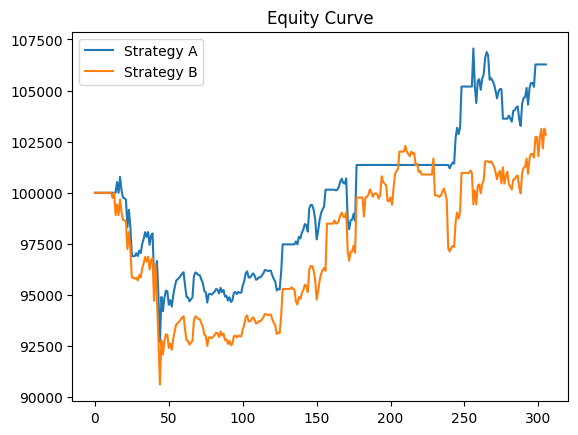

In [14]:
import matplotlib.pyplot as plt

plt.plot(equity_A, label="Strategy A")
plt.plot(equity_B, label="Strategy B")

plt.legend()
plt.title("Equity Curve")
plt.show()

In [15]:
import optuna
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# ======================
# 評価関数 (Updated to include Sharpe Ratio explicitly)
# ======================
def calc_metrics(equity):
    equity = np.array(equity)

    if len(equity) < 2:
        return { "PF": 0.0, "Expectancy": 0.0, "Max DD": 0.0, "Sharpe": 0.0, "Sortino": 0.0, "Stability": 0.0, "Total Trades": 0 }

    returns = np.diff(equity) / (equity[:-1] + 1e-9)

    # PF
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum()

    pf = gains / (losses + 1e-9)

    # Expectancy
    expectancy = returns.mean()

    # Max DD
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / (peak + 1e-9)
    max_dd = abs(dd.min())

    # Stability (inverse of volatility)
    vol = returns.std() + 1e-9
    stability = 1 / vol

    # Sharpe
    sharpe = expectancy / vol * np.sqrt(252)

    # Sortino (assuming risk-free rate is 0)
    downside = returns[returns < 0]

    if len(downside) < 3:
        sortino = 0.0   # Set to 0 if not enough data for downside deviation
    else:
        sortino = np.mean(returns) / (np.std(downside) + 1e-9)

    return {
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Stability": stability
    }


# ======================
# Optuna Objective (Refactored)
# ======================
def objective(trial):

    # ===== XGBoost model params =====
    model_params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 0.5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0)
    }

    # ===== Strategy parameters (Entry Ranking Model Weights) =====
    w_trend_strength = trial.suggest_float('w_trend_strength', 0.0, 5.0) # Weight for TREND_STRENGTH
    w_volatility_penalty = trial.suggest_float('w_volatility_penalty', 0.0, 5.0) # Weight for Volatility_Short (negative)
    w_momentum = trial.suggest_float('w_momentum', 0.0, 5.0) # Weight for RET_5

    # === New: Optimize Entry Threshold and ADX Filter ===
    entry_q = trial.suggest_float('entry_q', 0.7, 0.95)
    adx_th = trial.suggest_float('adx_th', 15, 30)
    use_slope = trial.suggest_categorical('use_slope', [True, False])

    # num_top_trades_per_fold is no longer optimized as per request

    # ===== Cross-validation =====
    tscv = TimeSeriesSplit(n_splits=5)

    all_sharpe_scores = []
    all_pf_scores = []
    all_expectancy_scores = []
    all_max_dd_scores = []
    all_trade_counts = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

        X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
        y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

        # SMOTE
        smote = SMOTE(random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)

        # Model training
        model = XGBClassifier(
            **model_params,
            random_state=42,
            eval_metric='logloss',
            n_jobs=-1
        )
        model.fit(X_train_res.values, y_train_res.values)

        # Prediction
        proba = model.predict_proba(X_test_cv.values)[:, 1]

        # Align df for signal generation
        df_slice = df.loc[X_test_cv.index].copy()
        df_slice["proba"] = proba

        # Ensure all required features for Entry Ranking Model are in df_slice
        df_slice['ADX'] = df.loc[X_test_cv.index, 'ADX']
        df_slice['Volatility_Short'] = df.loc[X_test_cv.index, 'Volatility_Short']
        df_slice['TREND_STRENGTH'] = df.loc[X_test_cv.index, 'TREND_STRENGTH']
        df_slice['RET_5'] = df.loc[X_test_cv.index, 'RET_5']

        # Calculate Entry Score based on optimized weights
        df_slice["entry_score"] = (
            df_slice["proba"] # Base probability from XGBoost
            + w_trend_strength * df_slice["TREND_STRENGTH"].abs() # Reward high trend strength
            - w_volatility_penalty * df_slice["Volatility_Short"] # Penalize high volatility
            + w_momentum * df_slice["RET_5"] # Reward momentum
        )

        # --- New Trend Filter Calculation (①) ---
        adx_rolling_mean = df_slice["ADX"].rolling(20, min_periods=1).mean()
        adx_slope = df_slice["ADX"].diff()
        adx_slope_mean = adx_slope.rolling(5, min_periods=1).mean()

        # Apply optimized ADX filter logic (②, ③)
        if use_slope:
            trend_filter = (adx_rolling_mean > adx_th) & (adx_slope_mean > 0)
        else:
            trend_filter = (adx_rolling_mean > adx_th)

        # Debugging logs as per point ④
        df_debug_obj = df_slice.copy()
        df_debug_obj["cond_score"] = df_debug_obj["entry_score"] > df_debug_obj["entry_score"].quantile(entry_q) # Changed to use entry_q
        df_debug_obj["cond_trend"] = trend_filter # Use the dynamically generated trend_filter
        df_debug_obj["cond_final"] = df_debug_obj["cond_score"] & df_debug_obj["cond_trend"]

        print(f"Fold {fold} - score通過率:", df_debug_obj["cond_score"].mean())
        print(f"Fold {fold} - trend通過率:", df_debug_obj["cond_trend"].mean())
        print(f"Fold {fold} - 最終通過率:", df_debug_obj["cond_final"].mean())


        # Initialize signals_series
        signals_series = pd.Series(0.0, index=df_slice.index)
        if not df_slice.empty:
            # Apply new signal generation: entry_score > dynamic_threshold AND trend_filter (②)
            signals_series = (
                (df_slice["entry_score"] > df_slice["entry_score"].quantile(entry_q)) & # Changed to use entry_q
                trend_filter
            ).astype(float)

            # Removed consecutive signal suppression (③ - test by completely removing)
            # signals_series = signals_series * (signals_series.shift(1).fillna(0) == 0).astype(float)

        # Backtest
        results, equity, _ = run_backtest(df, X_test_cv, signals_series)

        # Calculate all metrics including total trades
        metrics = calc_metrics(equity)

        # Penalty conditions (Guardrails - ⑤)
        if metrics["Max DD"] > 0.07:
            return -1e6
        if results["Total Trades"] < 8:
            return -1e6

        all_sharpe_scores.append(metrics["Sharpe"])
        all_pf_scores.append(metrics["PF"])
        all_expectancy_scores.append(metrics["Expectancy"])
        all_max_dd_scores.append(metrics["Max DD"])
        all_trade_counts.append(results["Total Trades"])

    # Final score based on Sharpe mean and std (④)
    if not all_sharpe_scores: # Handle case if all trials were pruned
        return -1e6

    final_score = np.mean(all_sharpe_scores) - 0.5 * np.std(all_sharpe_scores)
    return final_score

# ======================
# Optuna Study
# ======================
# The rest of the Optuna study setup should follow this function, e.g.:
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=100)
# best_params = study.best_params
# print("Best params:", best_params)

# For initial execution, we'll keep a placeholder comment. The user will run the study separately.

In [16]:
import optuna

# Create an Optuna study object and optimize the objective function
# The direction is 'maximize' because we want to maximize our custom objective (Sharpe, Expectancy, PF).
study = optuna.create_study(direction='maximize')

# Run the optimization for a specified number of trials.
# Adjust n_trials based on computational resources and desired search thoroughness.
study.optimize(objective, n_trials=50)

# Get the best parameters found by Optuna
best = study.best_params
print("Best trial:")
print(f"  Value: {study.best_value}")
print("  Params: ")
for key, value in best.items():
    print(f"    {key}: {value}")

# Store best params in `model_params` for subsequent cells
model_params = {
    k: best[k]
    for k in best
    if k in ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma', 'reg_alpha', 'reg_lambda']
}

[I 2026-04-25 18:09:53,904] A new study created in memory with name: no-name-2070647f-e9c0-4fd8-8629-fb7e7d9d8e42
[I 2026-04-25 18:09:54,143] Trial 0 finished with value: -1000000.0 and parameters: {'n_estimators': 194, 'max_depth': 5, 'learning_rate': 0.17467836090616587, 'subsample': 0.6104573789244806, 'colsample_bytree': 0.9653147112351121, 'gamma': 0.4537876203899179, 'reg_alpha': 0.1957836981704304, 'reg_lambda': 0.597927212534108, 'w_trend_strength': 4.342830116838248, 'w_volatility_penalty': 2.3439702077997113, 'w_momentum': 0.5803310270914802, 'entry_q': 0.7238746580072376, 'adx_th': 28.930047271276933, 'use_slope': True}. Best is trial 0 with value: -1000000.0.


Fold 0 - score通過率: 0.2784313725490196
Fold 0 - trend通過率: 0.22745098039215686
Fold 0 - 最終通過率: 0.11372549019607843
Fold 0 - score通過率: 0.12156862745098039
Fold 0 - trend通過率: 0.8235294117647058
Fold 0 - 最終通過率: 0.12156862745098039


[I 2026-04-25 18:09:54,340] Trial 1 finished with value: -1000000.0 and parameters: {'n_estimators': 99, 'max_depth': 6, 'learning_rate': 0.19420299726448415, 'subsample': 0.8848113256412391, 'colsample_bytree': 0.670220363195534, 'gamma': 0.07650419719962315, 'reg_alpha': 0.41396051290702407, 'reg_lambda': 0.5519192705312453, 'w_trend_strength': 0.5128962981577306, 'w_volatility_penalty': 4.150682254039962, 'w_momentum': 1.706521248244362, 'entry_q': 0.8780593304572788, 'adx_th': 21.93378268272933, 'use_slope': False}. Best is trial 0 with value: -1000000.0.
[I 2026-04-25 18:09:54,679] Trial 2 finished with value: -1000000.0 and parameters: {'n_estimators': 181, 'max_depth': 9, 'learning_rate': 0.08003444651721632, 'subsample': 0.6327424211032043, 'colsample_bytree': 0.6451836194336945, 'gamma': 0.1646853611023743, 'reg_alpha': 0.2067887418047426, 'reg_lambda': 1.298310973644949, 'w_trend_strength': 0.28816370937936486, 'w_volatility_penalty': 2.9999605636433913, 'w_momentum': 2.95077

Fold 0 - score通過率: 0.06666666666666667
Fold 0 - trend通過率: 0.3176470588235294
Fold 0 - 最終通過率: 0.043137254901960784


[I 2026-04-25 18:09:54,933] Trial 3 finished with value: -1000000.0 and parameters: {'n_estimators': 150, 'max_depth': 8, 'learning_rate': 0.1557398552465017, 'subsample': 0.6852478286836524, 'colsample_bytree': 0.7742173091071719, 'gamma': 0.2443654582005187, 'reg_alpha': 0.34932218674762183, 'reg_lambda': 1.3854563262944457, 'w_trend_strength': 3.038548275567315, 'w_volatility_penalty': 2.1749106673011305, 'w_momentum': 0.7407858771574355, 'entry_q': 0.8593658745327911, 'adx_th': 17.25488638868338, 'use_slope': True}. Best is trial 0 with value: -1000000.0.


...

Fold 1 - score通過率: 0.18823529411764706
Fold 1 - trend通過率: 0.8509803921568627
Fold 1 - 最終通過率: 0.18823529411764706
Fold 0 - score通過率: 0.20784313725490197
Fold 0 - trend通過率: 0.22745098039215686
Fold 0 - 最終通過率: 0.08627450980392157


[I 2026-04-25 18:10:14,271] Trial 47 finished with value: -1000000.0 and parameters: {'n_estimators': 117, 'max_depth': 9, 'learning_rate': 0.15278432110243503, 'subsample': 0.9726986421259733, 'colsample_bytree': 0.7037509142570126, 'gamma': 0.30877280861401557, 'reg_alpha': 0.4727958349810707, 'reg_lambda': 0.720421207271059, 'w_trend_strength': 0.2529878937995308, 'w_volatility_penalty': 0.9677625418727027, 'w_momentum': 2.5556098572400354, 'entry_q': 0.7935358038480601, 'adx_th': 29.072321397135624, 'use_slope': True}. Best is trial 0 with value: -1000000.0.


Fold 0 - score通過率: 0.16862745098039217
Fold 0 - trend通過率: 0.8745098039215686
Fold 0 - 最終通過率: 0.16862745098039217


[I 2026-04-25 18:10:14,988] Trial 48 finished with value: -1000000.0 and parameters: {'n_estimators': 77, 'max_depth': 10, 'learning_rate': 0.06120400780573674, 'subsample': 0.8742808901898091, 'colsample_bytree': 0.9124698779558681, 'gamma': 0.49274782155207314, 'reg_alpha': 0.28902949197953653, 'reg_lambda': 0.7812224436835316, 'w_trend_strength': 0.8079811272737729, 'w_volatility_penalty': 1.4819748035686766, 'w_momentum': 0.6044799113477826, 'entry_q': 0.8328797626213101, 'adx_th': 15.957846913626629, 'use_slope': False}. Best is trial 0 with value: -1000000.0.
[I 2026-04-25 18:10:15,131] Trial 49 finished with value: -1000000.0 and parameters: {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.030429055899655846, 'subsample': 0.8396513835524736, 'colsample_bytree': 0.6193396369012949, 'gamma': 0.15129808093102742, 'reg_alpha': 0.3588034651298739, 'reg_lambda': 0.5020886795104841, 'w_trend_strength': 4.717384047296743, 'w_volatility_penalty': 2.124565836055304, 'w_momentum': 3

Fold 1 - score通過率: 0.16862745098039217
Fold 1 - trend通過率: 0.9215686274509803
Fold 1 - 最終通過率: 0.16862745098039217
Fold 0 - score通過率: 0.08627450980392157
Fold 0 - trend通過率: 0.2980392156862745
Fold 0 - 最終通過率: 0.058823529411764705
Best trial:
  Value: -1000000.0
  Params: 
    n_estimators: 194
    max_depth: 5
    learning_rate: 0.17467836090616587
    subsample: 0.6104573789244806
    colsample_bytree: 0.9653147112351121
    gamma: 0.4537876203899179
    reg_alpha: 0.1957836981704304
    reg_lambda: 0.597927212534108
    w_trend_strength: 4.342830116838248
    w_volatility_penalty: 2.3439702077997113
    w_momentum: 0.5803310270914802
    entry_q: 0.7238746580072376
    adx_th: 28.930047271276933
    use_slope: True


In [17]:
print("proba exists:", "proba" in globals())

proba exists: False


In [18]:
model = XGBClassifier(
    **model_params,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

In [19]:
# ======================
# 最終モデル + 最終バックテスト（完成版）
# ======================

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# ======================
# パラメータ取得（-lj2XmmykqNY で抽出済みのものを使用）
# ======================

# model_params は -lj2XbSmf_r3a で定義済み
# 新しい戦略パラメータを best から取得

w_trend_strength = best.get("w_trend_strength")
w_volatility_penalty = best.get("w_volatility_penalty")
w_momentum = best.get("w_momentum")
entry_q = best.get("entry_q")
adx_th = best.get("adx_th")
use_slope = best.get("use_slope")

print("Final Model Params:", model_params)
print("Final Entry Ranking Model Weights: Trend Strength=", w_trend_strength, ", Volatility Penalty=", w_volatility_penalty, ", Momentum=", w_momentum)
print("Final Entry Filter Params: Entry Quantile=", entry_q, ", ADX Threshold=", adx_th, ", Use Slope=", use_slope)

# ======================
# 再学習
# ======================

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

final_model = XGBClassifier(
    **model_params,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

final_model.fit(X_train_resampled.values, y_train_resampled.values)

# ======================
# 予測
# ======================

proba_final = final_model.predict_proba(X_test.values)[:, 1]

# ======================
# 戦略生成（Simple Threshold Entry with Trend Filter and Consecutive Entry Prevention）
# ======================

df_test_slice = df.loc[X_test.index].copy()
df_test_slice["proba"] = proba_final

# Ensure all required features for Entry Ranking Model are in df_test_slice
df_test_slice['ADX'] = df.loc[X_test.index, 'ADX']
df_test_slice['Volatility_Short'] = df.loc[X_test.index, 'Volatility_Short']
df_test_slice['TREND_STRENGTH'] = df.loc[X_test.index, 'TREND_STRENGTH']
df_test_slice['RET_5'] = df.loc[X_test.index, 'RET_5']

# Calculate Entry Score based on optimized weights
df_test_slice["entry_score"] = (
    df_test_slice["proba"]
    + w_trend_strength * df_test_slice["TREND_STRENGTH"].abs()
    - w_volatility_penalty * df_test_slice["Volatility_Short"]
    + w_momentum * df_test_slice["RET_5"]
)

# --- New Trend Filter Calculation ---
adx_rolling_mean = df_test_slice["ADX"].rolling(20, min_periods=1).mean()
adx_slope = df_test_slice["ADX"].diff()
adx_slope_mean = adx_slope.rolling(5, min_periods=1).mean()

# Apply optimized ADX filter logic
if use_slope:
    trend_filter = (adx_rolling_mean > adx_th) & (adx_slope_mean > 0)
else:
    trend_filter = (adx_rolling_mean > adx_th)

# Apply new signal generation: entry_score > dynamic_threshold AND trend_filter
signals_final = (
    (df_test_slice["entry_score"] > df_test_slice["entry_score"].quantile(entry_q)) &
    trend_filter
).astype(float)

# Removed consecutive signal suppression (③ - test by completely removing)
# signals_final = signals_final * (signals_final.shift(1).fillna(0) == 0).astype(float)

signals_final = pd.Series(signals_final, index=X_test.index)

# ======================
# バックテスト
# ======================

results_final, equity_final, trade_pnls_final = run_backtest(
    df,
    X_test,
    signals_final
)

# ======================
# 結果
# ======================

print("===== FINAL RESULT ====")
for k, v in results_final.items():
    print(f"{k}: {v}")


Final Model Params: {'n_estimators': 194, 'max_depth': 5, 'learning_rate': 0.17467836090616587, 'subsample': 0.6104573789244806, 'colsample_bytree': 0.9653147112351121, 'gamma': 0.4537876203899179, 'reg_alpha': 0.1957836981704304, 'reg_lambda': 0.597927212534108}
Final Entry Ranking Model Weights: Trend Strength= 4.342830116838248 , Volatility Penalty= 2.3439702077997113 , Momentum= 0.5803310270914802
Final Entry Filter Params: Entry Quantile= 0.7238746580072376 , ADX Threshold= 28.930047271276933 , Use Slope= True
===== FINAL RESULT ====
Final Balance: 104772.12661515971
Total Return (%): 4.772126615159711
Total Trades: 7
Win Rate (%): 57.14285714285714
PF: 1.2675245116393468
Expectancy: 0.00015863195403522724
Max DD: -0.05135091978882583
Sharpe: 0.7408499676126714


In [20]:
# ======================
# トレードP/L分析
# ======================

if trade_pnls_final:
    winning_trades = [pnl for pnl in trade_pnls_final if pnl > 0]
    losing_trades = [pnl for pnl in trade_pnls_final if pnl < 0]

    avg_win = np.mean(winning_trades) if winning_trades else 0
    avg_loss = np.mean(losing_trades) if losing_trades else 0

    print(f"平均勝ちトレード金額: {avg_win:.2f}")
    print(f"平均負けトレード金額: {avg_loss:.2f}")
    print(f"リスクリワード比 (Avg Win / |Avg Loss|): {abs(avg_win / avg_loss):.2f}" if avg_loss != 0 else "リスクリワード比: N/A (負けトレードなし)")
else:
    print("トレード履歴がありません。")


平均勝ちトレード金額: 2675.98
平均負けトレード金額: -1977.27
リスクリワード比 (Avg Win / |Avg Loss|): 1.35


In [21]:
# ======================
# signalsの連打チェック
# ======================

# signals_finalのインデックスがDatetimeIndexであることを確認
if isinstance(signals_final.index, pd.DatetimeIndex):
    # 日付ごとにグループ化し、シグナルが1であるものの数をカウント
    # フィルタリングされたSeriesのインデックスを直接使うことで、Grouperとaxisの長さの不一致を解消
    filtered_signals = signals_final[signals_final == 1]
    daily_signals_count = filtered_signals.groupby(filtered_signals.index.date).count()

    # 1日に複数のシグナルが発生している日を抽出
    multiple_signals_days = daily_signals_count[daily_signals_count > 1]

    if not multiple_signals_days.empty:
        print("1日に複数のシグナルが発生している日があります:")
        print(multiple_signals_days)

        # 具体的なシグナルを表示するために、該当日のデータをフィルタリング
        for date_obj in multiple_signals_days.index:
            date = pd.Timestamp(date_obj)
            print(f"\n--- {date.date()} のシグナル ---")
            # ここでもfiltered_signalsから該当日のデータを取得するように修正
            print(filtered_signals.loc[date.date()])
    else:
        print("1日に複数のシグナルが発生している日はありません。")
else:
    print("signals_finalのインデックスがDatetimeIndexではありません。")


1日に複数のシグナルが発生している日はありません。


### `signals_final` のポジションサイズ分布の確認
`signals_final` の値が極端に小さい、または大きくなる可能性があるというご指摘を受け、その分布を確認します。これにより、トレードのポジションサイズが適切に調整されているか、または問題のある値が存在しないかを評価します。

signals_finalの記述統計量:
count    307.000000
mean       0.107492
std        0.310243
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
dtype: float64


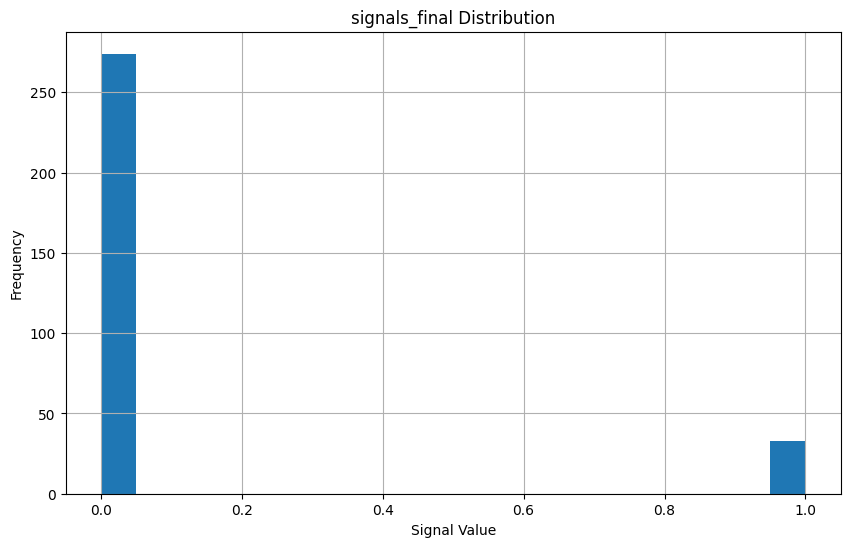

In [22]:
# ======================
# signals_finalの分布確認
# ======================

print("signals_finalの記述統計量:")
print(signals_final.describe())

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
signals_final.hist(bins=20)
plt.title('signals_final Distribution')
plt.xlabel('Signal Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


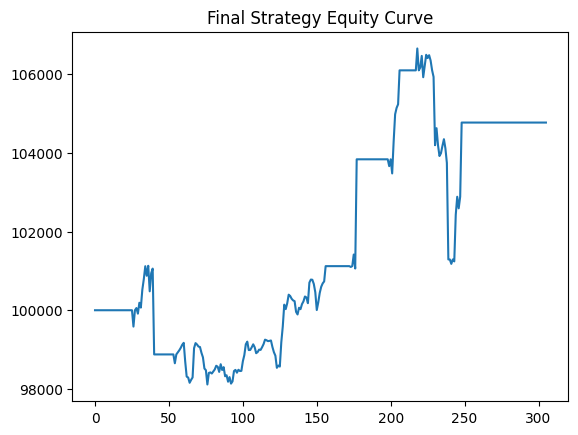

In [23]:
import matplotlib.pyplot as plt

plt.plot(equity_final)
plt.title("Final Strategy Equity Curve")
plt.show()

### `signals_final` とボラティリティの関係性の確認

`signals_final` のポジションサイズが低ボラティリティ環境で大きくなりすぎていないか確認するため、最終シグナル値とボラティリティ（`Volatility_Short`）の関係を散布図で可視化します。

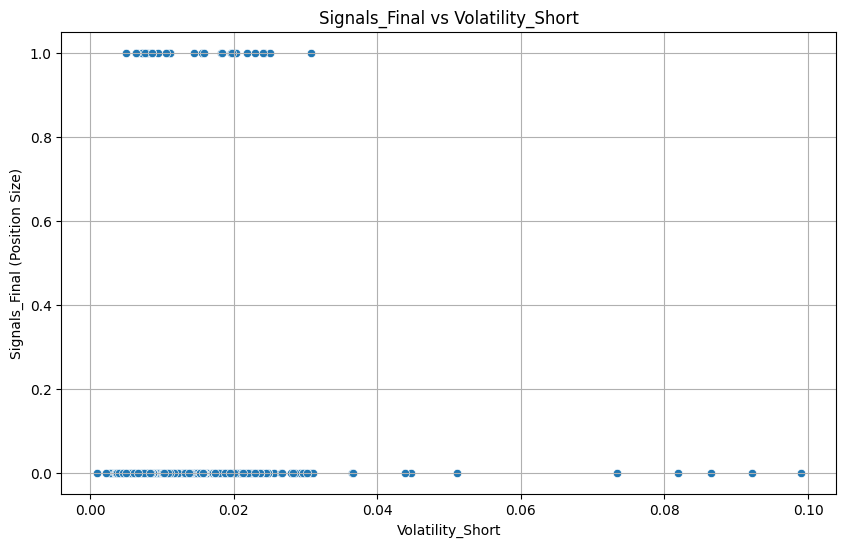

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# df_test_sliceはh_uXbSmf_r3aセルで定義されたものです。
# signals_finalはX_testのインデックスにアライメントされています。

# X_testの期間に対応するVolatility_Shortを取得
volatility_short_for_signals = df.loc[X_test.index, 'Volatility_Short']

# signals_finalとVolatility_Shortを結合してDataFrameを作成
plot_df = pd.DataFrame({
    'Signals_Final': signals_final,
    'Volatility_Short': volatility_short_for_signals
})

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Volatility_Short', y='Signals_Final', data=plot_df)
plt.title('Signals_Final vs Volatility_Short')
plt.xlabel('Volatility_Short')
plt.ylabel('Signals_Final (Position Size)')
plt.grid(True)
plt.show()


In [26]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

results_list = []
equity_curves = []

best_params_cv = study.best_params.copy()


# ======================
# 指標関数 (Updated to include Sharpe Ratio explicitly)
# ======================

def calc_metrics(equity):
    equity = np.array(equity)

    if len(equity) < 2:
        return { "PF": 0.0, "Expectancy": 0.0, "Max DD": 0.0, "Sharpe": 0.0, "Sortino": 0.0, "Stability": 0.0 }

    returns = np.diff(equity) / equity[:-1]

    # PF
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum()
    pf = gains / (losses + 1e-9)

    # Expectancy
    expectancy = returns.mean()

    # Max DD
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = dd.min()

    # Stability (inverse of volatility)
    vol = returns.std() + 1e-9
    stability = 1 / vol

    # Sharpe
    sharpe = expectancy / vol * np.sqrt(252)

    # Sortino (assuming risk-free rate is 0)
    downside = returns[returns < 0]

    if len(downside) < 3:
        sortino = 0.0   # Set to 0 if not enough data for downside deviation
    else:
        sortino = np.mean(returns) / (np.std(downside) + 1e-9)

    return {
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Stability": stability
    }


# ======================
# CV
# ======================

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    print(f"\n===== Fold {fold+1} ====")

    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    # Print the time range for the test set of the current fold
    print(f"Test period: {X_test_cv.index.min()} to {X_test_cv.index.max()}")

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)

    # model params
    # XGBoostモデルに渡すパラメータのみを抽出
    model_params_for_xgb = {
        k: best_params_cv[k]
        for k in best_params_cv
        if k in ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma', 'reg_alpha', 'reg_lambda']
    }

    model = XGBClassifier(
        **model_params_for_xgb,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )

    model.fit(X_train_res.values, y_train_res.values)

    # prediction
    proba = model.predict_proba(X_test_cv.values)[:, 1]

    # align df
    df_slice = df.loc[X_test_cv.index].copy()
    df_slice["proba"] = proba

    # Re-calculate required features for signal generation
    df_slice['ADX'] = df.loc[X_test_cv.index, 'ADX']
    df_slice['Volatility_Short'] = df.loc[X_test_cv.index, 'Volatility_Short']
    df_slice['TREND_STRENGTH'] = df.loc[X_test_cv.index, 'TREND_STRENGTH']
    df_slice['RET_5'] = df.loc[X_test_cv.index, 'RET_5'] # Add RET_5 for the new Entry Ranking Model

    # Retrieve Entry Ranking Model weights and new filter parameters
    w_trend_strength_cv = best_params_cv.get("w_trend_strength")
    w_volatility_penalty_cv = best_params_cv.get("w_volatility_penalty")
    w_momentum_cv = best_params_cv.get("w_momentum")
    entry_q_cv = best_params_cv.get("entry_q")
    adx_th_cv = best_params_cv.get("adx_th")
    use_slope_cv = best_params_cv.get("use_slope")

    # Calculate Entry Score based on optimized weights
    df_slice["entry_score"] = (
        df_slice["proba"]
        + w_trend_strength_cv * df_slice["TREND_STRENGTH"].abs()
        - w_volatility_penalty_cv * df_slice["Volatility_Short"]
        + w_momentum_cv * df_slice["RET_5"]
    )

    # --- New Trend Filter Calculation ---
    adx_rolling_mean = df_slice["ADX"].rolling(20, min_periods=1).mean()
    adx_slope = df_slice["ADX"].diff()
    adx_slope_mean = adx_slope.rolling(5, min_periods=1).mean()

    # Apply optimized ADX filter logic
    if use_slope_cv:
        trend_filter = (adx_rolling_mean > adx_th_cv) & (adx_slope_mean > 0)
    else:
        trend_filter = (adx_rolling_mean > adx_th_cv)

    # Debugging logs as per point ④
    df_debug_cv = df_slice.copy()
    df_debug_cv["cond_score"] = df_debug_cv["entry_score"] > df_debug_cv["entry_score"].quantile(entry_q_cv)
    df_debug_cv["cond_trend"] = trend_filter
    df_debug_cv["cond_final"] = df_debug_cv["cond_score"] & df_debug_cv["cond_trend"]

    print(f"Fold {fold+1} - score通過率:", df_debug_cv["cond_score"].mean())
    print(f"Fold {fold+1} - trend通過率:", df_debug_cv["cond_trend"].mean())
    print(f"Fold {fold+1} - 最終通過率:", df_debug_cv["cond_final"].mean())

    # Apply new signal generation: entry_score > dynamic_threshold AND trend_filter
    signals_series = pd.Series(0.0, index=df_slice.index)
    if not df_slice.empty:
        signals_series = (
            (df_slice["entry_score"] > df_slice["entry_score"].quantile(entry_q_cv)) &
            trend_filter
        ).astype(float)

        # Removed consecutive signal suppression (③ - test by completely removing)
        # signals_series = signals_series * (signals_series.shift(1).fillna(0) == 0).astype(float)


    # backtest
    results, equity, _ = run_backtest(
        df,
        X_test_cv,
        signals_series
    )

    # ======================
    # 追加：全部の指標
    # ======================
    metrics = calc_metrics(equity)
    results.update(metrics)

    results_list.append(results)
    equity_curves.append(equity)

    print(results)


# ======================
# summary
# ======================

df_results = pd.DataFrame(results_list)

print("\n===== CV SUMMARY ====")
print(df_results.mean())

print("\nSTD:")
print(df_results.std())


===== Fold 1 ====
Test period: 2021-03-29 00:00:00 to 2022-03-30 00:00:00
Fold 1 - score通過率: 0.2784313725490196
Fold 1 - trend通過率: 0.22745098039215686
Fold 1 - 最終通過率: 0.11372549019607843
{'Final Balance': np.float64(106180.29050557196), 'Total Return (%)': np.float64(6.1802905055719615), 'Total Trades': 7, 'Win Rate (%)': 57.14285714285714, 'PF': np.float64(1.3181136007338963), 'Expectancy': np.float64(0.0002456032191877653), 'Max DD': np.float64(-0.026452294509923972), 'Sharpe': np.float64(0.940617978165967), 'Sortino': np.float64(0.06682423582016037), 'Stability': np.float64(241.25645936580534)}

===== Fold 2 ====
Test period: 2022-03-31 00:00:00 to 2023-04-05 00:00:00
Fold 2 - score通過率: 0.2784313725490196
Fold 2 - trend通過率: 0.19607843137254902
Fold 2 - 最終通過率: 0.11372549019607843
{'Final Balance': np.float64(94731.01122739432), 'Total Return (%)': np.float64(-5.268988772605676), 'Total Trades': 6, 'Win Rate (%)': 16.666666666666664, 'PF': np.float64(0.7119249802813857), 'Expectancy'

In [27]:
X.index.equals(df.index)

True

In [28]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

results_list = []
equity_curves = []

best_params_cv = study.best_params.copy()


# ======================
# 指標関数 (Updated to include Sharpe Ratio explicitly)
# ======================

def calc_metrics(equity):
    equity = np.array(equity)

    if len(equity) < 2:
        return { "PF": 0.0, "Expectancy": 0.0, "Max DD": 0.0, "Sharpe": 0.0, "Sortino": 0.0, "Stability": 0.0 }

    returns = np.diff(equity) / equity[:-1]

    # PF
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum()
    pf = gains / (losses + 1e-9)

    # Expectancy
    expectancy = returns.mean()

    # Max DD
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = dd.min()

    # Stability (inverse of volatility)
    vol = returns.std() + 1e-9
    stability = 1 / vol

    # Sharpe
    sharpe = expectancy / vol * np.sqrt(252)

    # Sortino (assuming risk-free rate is 0)
    downside = returns[returns < 0]

    if len(downside) < 3:
        sortino = 0.0   # Set to 0 if not enough data for downside deviation
    else:
        sortino = np.mean(returns) / (np.std(downside) + 1e-9)

    return {
        "PF": pf,
        "Expectancy": expectancy,
        "Max DD": max_dd,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Stability": stability
    }


# ======================
# CV
# ======================

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    print(f"\n===== Fold {fold+1} ====")

    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    # Print the time range for the test set of the current fold
    print(f"Test period: {X_test_cv.index.min()} to {X_test_cv.index.max()}")

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)

    # model params
    # XGBoostモデルに渡すパラメータのみを抽出
    model_params_for_xgb = {
        k: best_params_cv[k]
        for k in best_params_cv
        if k in ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma', 'reg_alpha', 'reg_lambda']
    }

    model = XGBClassifier(
        **model_params_for_xgb,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )

    model.fit(X_train_res.values, y_train_res.values)

    # prediction
    proba = model.predict_proba(X_test_cv.values)[:, 1]

    # align df
    df_slice = df.loc[X_test_cv.index].copy()
    df_slice["proba"] = proba

    # Re-calculate required features for signal generation
    df_slice['ADX'] = df.loc[X_test_cv.index, 'ADX']
    df_slice['Volatility_Short'] = df.loc[X_test_cv.index, 'Volatility_Short']
    df_slice['TREND_STRENGTH'] = df.loc[X_test_cv.index, 'TREND_STRENGTH']
    df_slice['RET_5'] = df.loc[X_test_cv.index, 'RET_5'] # Add RET_5 for the new Entry Ranking Model

    # Retrieve Entry Ranking Model weights and new filter parameters
    w_trend_strength_cv = best_params_cv.get("w_trend_strength")
    w_volatility_penalty_cv = best_params_cv.get("w_volatility_penalty")
    w_momentum_cv = best_params_cv.get("w_momentum")
    entry_q_cv = best_params_cv.get("entry_q")
    adx_th_cv = best_params_cv.get("adx_th")
    use_slope_cv = best_params_cv.get("use_slope")

    # Calculate Entry Score based on optimized weights
    df_slice["entry_score"] = (
        df_slice["proba"]
        + w_trend_strength_cv * df_slice["TREND_STRENGTH"].abs()
        - w_volatility_penalty_cv * df_slice["Volatility_Short"]
        + w_momentum_cv * df_slice["RET_5"]
    )

    # --- New Trend Filter Calculation ---
    adx_rolling_mean = df_slice["ADX"].rolling(20, min_periods=1).mean()
    adx_slope = df_slice["ADX"].diff()
    adx_slope_mean = adx_slope.rolling(5, min_periods=1).mean()

    # Apply optimized ADX filter logic
    if use_slope_cv:
        trend_filter = (adx_rolling_mean > adx_th_cv) & (adx_slope_mean > 0)
    else:
        trend_filter = (adx_rolling_mean > adx_th_cv)

    # Debugging logs as per point ④
    df_debug_cv = df_slice.copy()
    df_debug_cv["cond_score"] = df_debug_cv["entry_score"] > df_debug_cv["entry_score"].quantile(entry_q_cv)
    df_debug_cv["cond_trend"] = trend_filter
    df_debug_cv["cond_final"] = df_debug_cv["cond_score"] & df_debug_cv["cond_trend"]

    print(f"Fold {fold+1} - score通過率:", df_debug_cv["cond_score"].mean())
    print(f"Fold {fold+1} - trend通過率:", df_debug_cv["cond_trend"].mean())
    print(f"Fold {fold+1} - 最終通過率:", df_debug_cv["cond_final"].mean())

    # Apply new signal generation: entry_score > dynamic_threshold AND trend_filter
    signals_series = pd.Series(0.0, index=df_slice.index)
    if not df_slice.empty:
        signals_series = (
            (df_slice["entry_score"] > df_slice["entry_score"].quantile(entry_q_cv)) &
            trend_filter
        ).astype(float)

        # Removed consecutive signal suppression (③ - test by completely removing)
        # signals_series = signals_series * (signals_series.shift(1).fillna(0) == 0).astype(float)


    # backtest
    results, equity, _ = run_backtest(
        df,
        X_test_cv,
        signals_series
    )

    # ======================
    # 追加：全部の指標
    # ======================
    metrics = calc_metrics(equity)
    results.update(metrics)

    results_list.append(results)
    equity_curves.append(equity)

    print(results)


# ======================
# summary
# ======================

df_results = pd.DataFrame(results_list)

print("\n===== CV SUMMARY ====")
print(df_results.mean())

print("\nSTD:")
print(df_results.std())


===== Fold 1 ====
Test period: 2021-03-29 00:00:00 to 2022-03-30 00:00:00
Fold 1 - score通過率: 0.2784313725490196
Fold 1 - trend通過率: 0.22745098039215686
Fold 1 - 最終通過率: 0.11372549019607843
{'Final Balance': np.float64(106180.29050557196), 'Total Return (%)': np.float64(6.1802905055719615), 'Total Trades': 7, 'Win Rate (%)': 57.14285714285714, 'PF': np.float64(1.3181136007338963), 'Expectancy': np.float64(0.0002456032191877653), 'Max DD': np.float64(-0.026452294509923972), 'Sharpe': np.float64(0.940617978165967), 'Sortino': np.float64(0.06682423582016037), 'Stability': np.float64(241.25645936580534)}

===== Fold 2 ====
Test period: 2022-03-31 00:00:00 to 2023-04-05 00:00:00
Fold 2 - score通過率: 0.2784313725490196
Fold 2 - trend通過率: 0.19607843137254902
Fold 2 - 最終通過率: 0.11372549019607843
{'Final Balance': np.float64(94731.01122739432), 'Total Return (%)': np.float64(-5.268988772605676), 'Total Trades': 6, 'Win Rate (%)': 16.666666666666664, 'PF': np.float64(0.7119249802813857), 'Expectancy'

In [29]:
print('ADX' in df.columns)
print(df.columns)

True
Index(['Close', 'High', 'Low', 'Volume', 'SMA_5', 'SMA_25', 'SMA_DIFF',
       'SMA_RATIO', 'Target', 'RSI', 'MACD', 'Signal_Line', 'MACD_Hist',
       'Daily_Return', 'Volatility_Short', 'ATR', 'RET_3', 'RET_5', 'RET_10',
       'VOL_10', 'VOL_20', 'VOL_RATIO', 'RANGE_SCORE', 'MOMENTUM', 'ADX',
       'TREND_STRENGTH', 'Upper_BB', 'Lower_BB', 'BB_Width', 'Close_Lag_1',
       'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_4', 'Close_Lag_5',
       'ADX_normalized', 'trend_regime'],
      dtype='object')


In [30]:
df_debug = df_slice.copy()

# 条件ごとにTrue/Falseを記録
df_debug["cond_proba"] = df_debug["proba"] > df_debug["proba"].quantile(0.9)
df_debug["cond_trend"] = trend_filter
df_debug["cond_final"] = (df_debug["cond_proba"] & df_debug["cond_trend"])

# 通過率確認
print("proba通過率:", df_debug["cond_proba"].mean())
print("trend通過率:", df_debug["cond_trend"].mean())
print("最終通過率:", df_debug["cond_final"].mean())

proba通過率: 0.10196078431372549
trend通過率: 0.22745098039215686
最終通過率: 0.011764705882352941
